# Задание 1. Считайте датасет из файла loan_prediction_dataset.csv

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno

df = pd.read_csv("loan_prediction_dataset.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Задание 2. Выведите основную информацию о датасете (info(), describe())

In [22]:
print("Dataset shape:", df.shape)

print("\nDataset info:")
df.info()

print("\nAll features summary:")
display(df.describe(include="all"))

Dataset shape: (614, 13)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

All features summary:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


### **Интерпретация:**
*В датасете 614 строк и 13 столбцов. В таблице есть как числовые, так и категориальные признаки. По выводу info() видно, что не все столбцы заполнены полностью, значит в данных есть пропуски.*

# Задание 3. Выведите таблицу пропусков по каждому столбцу: абсолютное число и процент пропусков

In [23]:
mis_val = df.isnull().sum()
mis_val_percent = 100 * df.isnull().sum() / len(df)

mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

mis_val_table = mis_val_table.rename(
    columns={0: "Пропущенных значений", 1: "% от общего количества"}
)

mis_val_table = mis_val_table[
    mis_val_table.iloc[:, 0] != 0
].sort_values("% от общего количества", ascending=False).round(2)

mis_val_table

,Пропущенных значений,% от общего количества
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


# Задание 4. Постройте визуализации пропусков: матрицу пропусков и тепловую карту пропусков

## **Матрица пропусков**

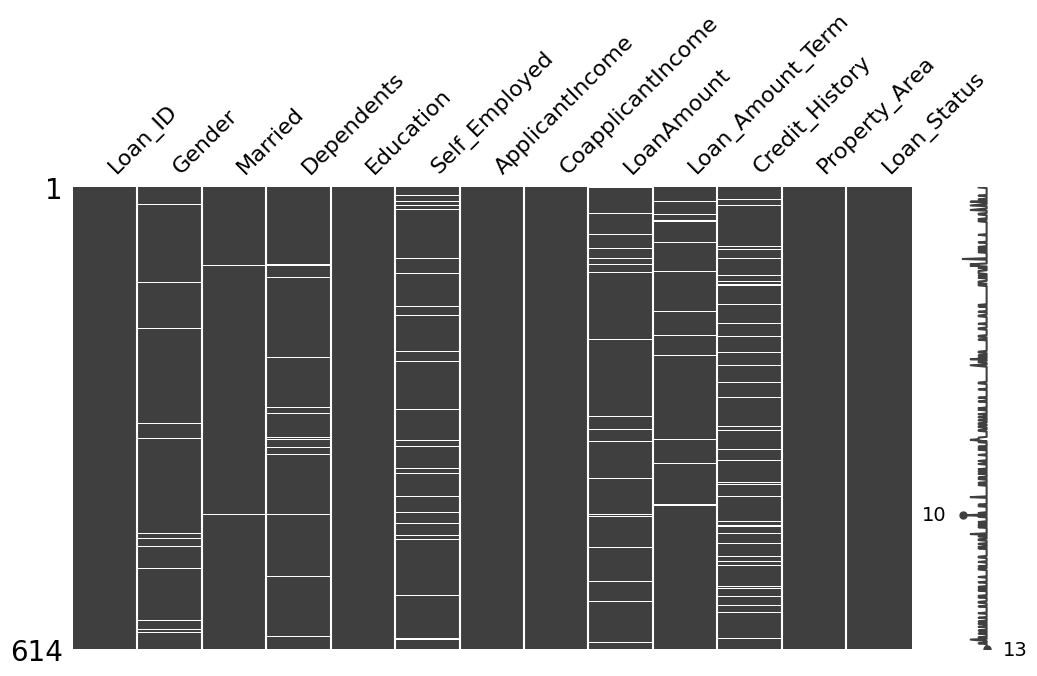

In [24]:
msno.matrix(df, figsize=(12, 6))
plt.show()

## **Тепловая карта пропусков**

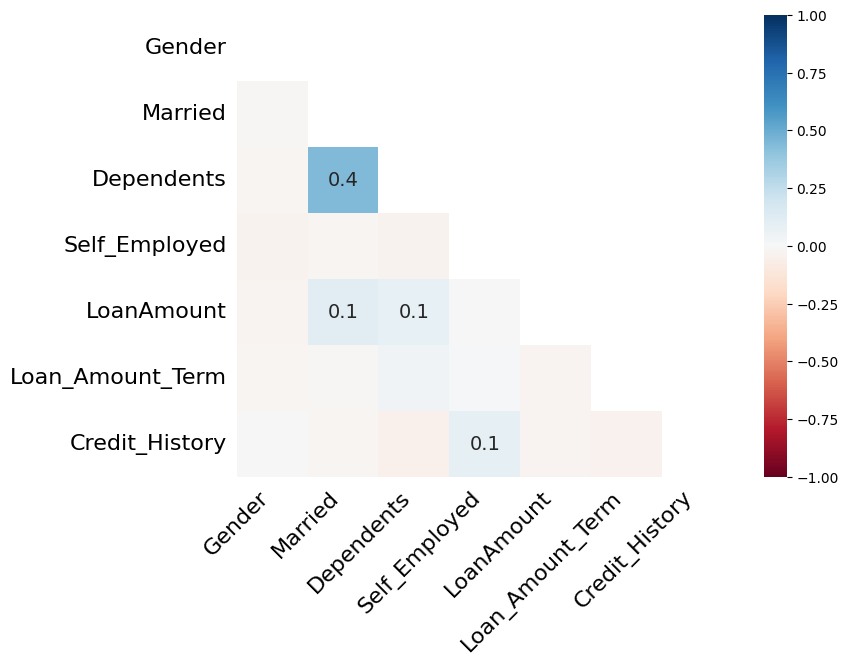

In [25]:
msno.heatmap(df, figsize=(8, 6))
plt.show()

# Задание 5. Проинтерпретируйте полученные графики
### **Интерпретация матрицы пропусков:**
*Матрица пропусков позволяет увидеть, в каких местах датасета отсутствуют значения. Белые участки соответствуют пропускам. Видно, что пропуски встречаются в нескольких столбцах, но не образуют одного большого сплошного блока. Это значит, что отсутствующие значения распределены по строкам достаточно рассеянно.*

### **Интерпретация тепловой карты пропусков:**
*Тепловая карта показывает взаимосвязь между пропусками в разных признаках. Сильной корреляции между пропусками здесь не видно, значит пропуски в одном столбце обычно не тянут за собой пропуски в другом. Это упрощает обработку, потому что признаки можно заполнять отдельно.*

# Задание 6. Разделите признаки с пропусками на числовые и категориальные

In [26]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

numeric_with_missing = numeric_cols[df[numeric_cols].isnull().any()]
categorical_with_missing = categorical_cols[df[categorical_cols].isnull().any()]

print("Числовые признаки с пропусками:")
print(list(numeric_with_missing))

print("\nКатегориальные признаки с пропусками:")
print(list(categorical_with_missing))

Числовые признаки с пропусками:
['LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Категориальные признаки с пропусками:
['Gender', 'Married', 'Dependents', 'Self_Employed']


# Задание 7. Заполните пропуски (обоснуйте выбор метода для каждого типа признаков)

In [27]:
df_filled = df.copy()

### **Заполнение категориальных признаков модой**

In [28]:
for col in ["Gender", "Married", "Dependents", "Self_Employed"]:
    df_filled[col] = df_filled[col].fillna(df_filled[col].mode()[0])

*Для категориальных признаков используется мода, потому что она подставляет самое часто встречающееся значение. Такой способ не создаёт новых категорий и хорошо подходит для признаков с текстовыми значениями.*

### **Заполнение числовых признаков медианой**

In [29]:
for col in ["LoanAmount", "Loan_Amount_Term"]:
    df_filled[col] = df_filled[col].fillna(df_filled[col].median())

*Для числовых признаков LoanAmount и Loan_Amount_Term выбрана медиана, так как она меньше зависит от выбросов, чем среднее значение. Поэтому такое заполнение считается более устойчивым.*

### **Заполнение Credit_History модой**

In [30]:
df_filled["Credit_History"] = df_filled["Credit_History"].fillna(
    df_filled["Credit_History"].mode()[0]
)

*Для признака Credit_History также выбрана мода, потому что этот признак по смыслу является бинарным. В таком случае логично подставить наиболее часто встречающееся значение.*

# Задание 8. Проверьте, что пропуски заполнены корректно

In [31]:
df_filled.isnull().sum()
df_filled.isnull().sum().sum()

np.int64(0)

# Задание 9. Покажите статистики до/после заполнения и кратко прокомментируйте изменения

### **Статистики до заполнения**

In [32]:
cols_with_missing = ["Gender", "Married", "Dependents", "Self_Employed",
                     "LoanAmount", "Loan_Amount_Term", "Credit_History"]

df[cols_with_missing].describe(include="all")

,Gender,Married,Dependents,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History
count,601,611,599,582,592.000000,600.00000,564.000000
unique,2,2,4,2,NaN,NaN,NaN
top,Male,Yes,0,No,NaN,NaN,NaN
freq,489,398,345,500,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,146.412162,342.00000,0.842199
std,NaN,NaN,NaN,NaN,85.587325,65.12041,0.364878
min,NaN,NaN,NaN,NaN,9.000000,12.00000,0.000000
25%,NaN,NaN,NaN,NaN,100.000000,360.00000,1.000000
50%,NaN,NaN,NaN,NaN,128.000000,360.00000,1.000000
75%,NaN,NaN,NaN,NaN,168.000000,360.00000,1.000000


### **Статистики после заполнения**

In [33]:
df_filled[cols_with_missing].describe(include="all")

,Gender,Married,Dependents,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History
count,614,614,614,614,614.000000,614.000000,614.000000
unique,2,2,4,2,NaN,NaN,NaN
top,Male,Yes,0,No,NaN,NaN,NaN
freq,502,401,360,532,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,145.752443,342.410423,0.855049
std,NaN,NaN,NaN,NaN,84.107233,64.428629,0.352339
min,NaN,NaN,NaN,NaN,9.000000,12.000000,0.000000
25%,NaN,NaN,NaN,NaN,100.250000,360.000000,1.000000
50%,NaN,NaN,NaN,NaN,128.000000,360.000000,1.000000
75%,NaN,NaN,NaN,NaN,164.750000,360.000000,1.000000


### **Сравнение числовых признаков до и после заполнения**

In [34]:
cols = ["LoanAmount", "Loan_Amount_Term", "Credit_History"]

numeric_compare = pd.DataFrame({
    "count_before": df[cols].count(),
    "count_after": df_filled[cols].count(),
    "mean_before": df[cols].mean(),
    "mean_after": df_filled[cols].mean(),
    "median_before": df[cols].median(),
    "median_after": df_filled[cols].median(),
}).round(2)

numeric_compare

,count_before,count_after,mean_before,mean_after,median_before,median_after
LoanAmount,592,614,146.41,145.75,128.0,128.0
Loan_Amount_Term,600,614,342.00,342.41,360.0,360.0
Credit_History,564,614,0.84,0.86,1.0,1.0


### **Комментарий**

После заполнения пропусков все значения в признаках `LoanAmount`, `Loan_Amount_Term` и `Credit_History` стали заполнены.  
Среднее значение и медиана изменились совсем незначительно, поэтому можно сделать вывод, что обработка пропусков не оказала сильного влияния на общую структуру данных.  

В категориальных признаках чаще стали встречаться наиболее популярные значения, так как именно ими были заменены пропуски.